# ML4QS Group 40 — Classical ML Modelling
**Wrist-Based Activity Recognition**  
Aniket Dasurkar, Mansi Saxena, Shreya Bhatt — Vrije Universiteit Amsterdam

This notebook trains and evaluates classical (non-time-series) ML classifiers on the feature matrix produced by `03_feature_engineering.ipynb`.

Models trained:
1. **k-Nearest Neighbours (kNN)** — distance-based, no assumptions about data distribution
2. **Decision Tree** — interpretable, single tree baseline
3. **Random Forest** — ensemble of trees, handles high-dimensional feature spaces well
4. **Support Vector Machine (SVM)** — margin-based, strong on normalised feature vectors
5. **Naive Bayes** — probabilistic baseline, fast, assumes feature independence

Evaluation:
- Accuracy, precision, recall, F1-score per class
- Confusion matrices
- Feature importance (Random Forest)
- Cross-validation
- Model comparison summary


## 0 · Imports & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score,
                             f1_score, precision_score, recall_score)
from sklearn.inspection import permutation_importance

OUTPUT_DIR = Path("outputs/")
(OUTPUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "eda").mkdir(parents=True, exist_ok=True)

ACTIVITIES = ["smoking", "typing", "idle", "cooking", "exercising"]
PALETTE    = dict(zip(ACTIVITIES,
                      ["#e63946","#457b9d","#6a994e","#e9c46a","#f4a261"]))

# ── Load feature arrays ────────────────────────────────────────────────────────
X_train = np.load("outputs/features/X_train.npy")
X_test  = np.load("outputs/features/X_test.npy")
y_train = np.load("outputs/features/y_train.npy")
y_test  = np.load("outputs/features/y_test.npy")

with open("outputs/features/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)
with open("outputs/features/feat_cols.pkl", "rb") as f:
    feat_cols = pickle.load(f)

CLASS_NAMES = list(le.classes_)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {CLASS_NAMES}")
print(f"Features: {len(feat_cols)}")
print(f"\nClass distribution (train):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<12}: {(y_train==i).sum():,} windows")
print(f"\nClass distribution (test):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<12}: {(y_test==i).sum():,} windows")


X_train : (2240, 249)
X_test  : (1120, 249)
Classes : [np.str_('cooking'), np.str_('exercising'), np.str_('idle'), np.str_('smoking'), np.str_('typing')]
Features: 249

Class distribution (train):
  cooking     : 448 windows
  exercising  : 448 windows
  idle        : 448 windows
  smoking     : 448 windows
  typing      : 448 windows

Class distribution (test):
  cooking     : 224 windows
  exercising  : 224 windows
  idle        : 224 windows
  smoking     : 224 windows
  typing      : 224 windows


In [4]:
y_test

array([0, 0, 0, ..., 4, 4, 4], shape=(1120,))

## 1 · Evaluation Helpers

In [5]:
def evaluate_model(model, X_test, y_test, class_names, model_name):
    """
    Full evaluation: accuracy, per-class metrics, confusion matrix.
    Returns a summary dict.
    """
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred, average="macro")
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  Macro F1       : {f1:.4f}")
    print(f"  Macro Precision: {prec:.4f}")
    print(f"  Macro Recall   : {rec:.4f}")
    print(f"\nPer-class report:")
    print(classification_report(y_test, y_pred,
                                target_names=class_names,
                                digits=3))
    return {
        "model":     model_name,
        "accuracy":  acc,
        "f1_macro":  f1,
        "precision": prec,
        "recall":    rec,
        "y_pred":    y_pred
    }


def plot_confusion_matrix(y_test, y_pred, class_names, title, ax=None):
    """Plot a clean normalised confusion matrix."""
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)


results = []  # collect all model results here


## 2 · k-Nearest Neighbours (kNN)

**Rationale:** kNN is a non-parametric, instance-based classifier that makes no assumptions about the data distribution. It classifies a window by the majority vote of its k nearest neighbours in feature space. It serves as a strong interpretable baseline and works well when classes form compact clusters in feature space — which we expect here since activities have distinct signal profiles.

**Hyperparameter tuning:** We test k = 1, 3, 5, 7, 9, 11 and select the best k by cross-validation on the training set.


  k= 1  CV accuracy: 0.9955 ± 0.0042
  k= 3  CV accuracy: 0.9955 ± 0.0032
  k= 5  CV accuracy: 0.9942 ± 0.0039
  k= 7  CV accuracy: 0.9938 ± 0.0038
  k= 9  CV accuracy: 0.9920 ± 0.0054
  k=11  CV accuracy: 0.9911 ± 0.0053
  k=15  CV accuracy: 0.9893 ± 0.0061

→ Best k: 1 (CV accuracy: 0.9955)


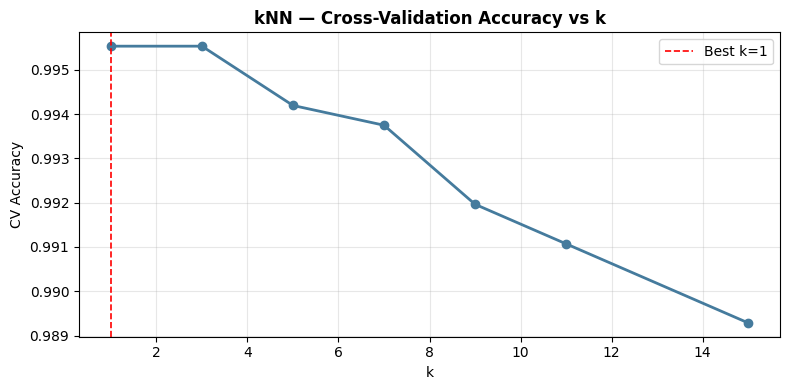

In [6]:
# ── Find best k by cross-validation ──────────────────────────────────────────
k_values = [1, 3, 5, 7, 9, 11, 15]
cv_scores = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean", n_jobs=-1)
    scores = cross_val_score(knn, X_train, y_train, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    cv_scores.append(scores.mean())
    print(f"  k={k:2d}  CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

best_k = k_values[np.argmax(cv_scores)]
print(f"\n→ Best k: {best_k} (CV accuracy: {max(cv_scores):.4f})")

# Plot CV scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_values, cv_scores, marker="o", color="#457b9d", linewidth=2)
ax.axvline(best_k, color="red", linestyle="--", linewidth=1.2,
           label=f"Best k={best_k}")
ax.set_xlabel("k")
ax.set_ylabel("CV Accuracy")
ax.set_title("kNN — Cross-Validation Accuracy vs k", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/eda/knn_cv_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()



  kNN (k=1)
  Accuracy       : 0.8857
  Macro F1       : 0.8858
  Macro Precision: 0.8911
  Macro Recall   : 0.8857

Per-class report:
              precision    recall  f1-score   support

     cooking      0.824     0.875     0.848       224
  exercising      0.876     0.853     0.864       224
        idle      0.991     0.951     0.970       224
     smoking      0.941     0.790     0.859       224
      typing      0.824     0.960     0.887       224

    accuracy                          0.886      1120
   macro avg      0.891     0.886     0.886      1120
weighted avg      0.891     0.886     0.886      1120



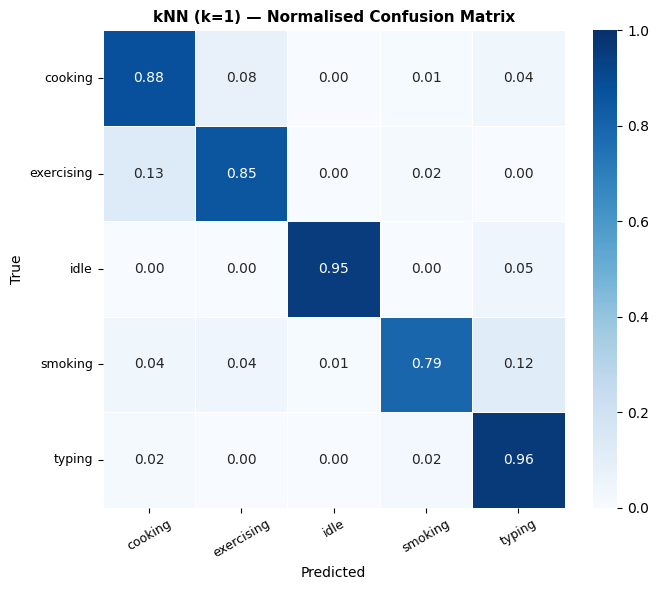

In [7]:
# ── Train & evaluate best kNN ─────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean", n_jobs=-1)
knn.fit(X_train, y_train)

res_knn = evaluate_model(knn, X_test, y_test, CLASS_NAMES, f"kNN (k={best_k})")
results.append(res_knn)

plot_confusion_matrix(y_test, res_knn["y_pred"], CLASS_NAMES,
                      f"kNN (k={best_k}) — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/eda/cm_knn.png", dpi=150, bbox_inches="tight")
plt.show()


## 3 · Decision Tree

**Rationale:** A single decision tree is the most interpretable classifier — the learned rules can be read directly and explained to a non-technical audience. It also reveals which features the model considers most discriminative at the top of the tree. It is expected to underperform Random Forest but provides a useful interpretability baseline.

**Hyperparameter:** We tune `max_depth` by cross-validation to prevent overfitting — an unconstrained tree will perfectly memorise the training set.


In [8]:
# ── Tune max_depth ────────────────────────────────────────────────────────────
depths     = [3, 5, 7, 10, 15, 20, None]
depth_cvs  = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42,
                                criterion="gini")
    scores = cross_val_score(dt, X_train, y_train, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    depth_cvs.append(scores.mean())
    label = str(d) if d else "None"
    print(f"  max_depth={label:<5}  CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

best_depth = depths[np.argmax(depth_cvs)]
print(f"\n→ Best max_depth: {best_depth} (CV accuracy: {max(depth_cvs):.4f})")


  max_depth=3      CV accuracy: 0.9147 ± 0.0126
  max_depth=5      CV accuracy: 0.9589 ± 0.0078
  max_depth=7      CV accuracy: 0.9728 ± 0.0133
  max_depth=10     CV accuracy: 0.9728 ± 0.0094
  max_depth=15     CV accuracy: 0.9719 ± 0.0102
  max_depth=20     CV accuracy: 0.9719 ± 0.0102
  max_depth=None   CV accuracy: 0.9719 ± 0.0102

→ Best max_depth: 7 (CV accuracy: 0.9728)



  Decision Tree (max_depth=7)
  Accuracy       : 0.8250
  Macro F1       : 0.8197
  Macro Precision: 0.8282
  Macro Recall   : 0.8250

Per-class report:
              precision    recall  f1-score   support

     cooking      0.741     0.536     0.622       224
  exercising      0.728     0.933     0.818       224
        idle      0.937     1.000     0.968       224
     smoking      0.770     0.808     0.789       224
      typing      0.964     0.848     0.903       224

    accuracy                          0.825      1120
   macro avg      0.828     0.825     0.820      1120
weighted avg      0.828     0.825     0.820      1120



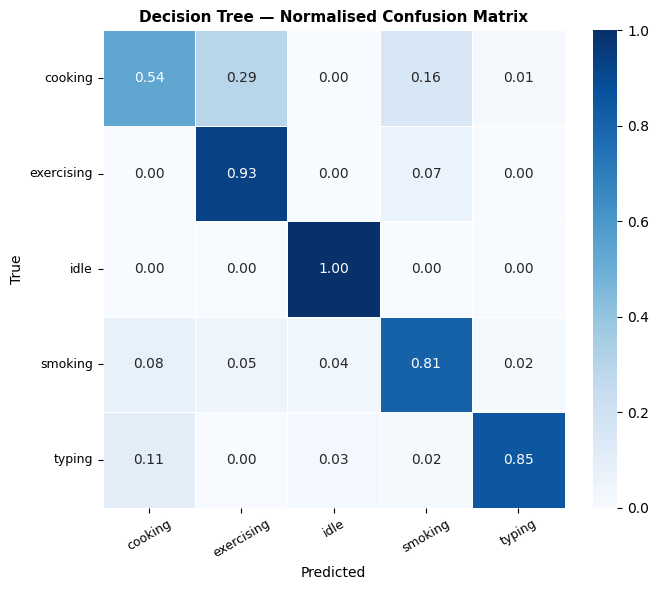

In [9]:
# ── Train & evaluate best Decision Tree ───────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42,
                             criterion="gini")
dt.fit(X_train, y_train)

res_dt = evaluate_model(dt, X_test, y_test, CLASS_NAMES,
                        f"Decision Tree (max_depth={best_depth})")
results.append(res_dt)

plot_confusion_matrix(y_test, res_dt["y_pred"], CLASS_NAMES,
                      f"Decision Tree — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/eda/cm_decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()


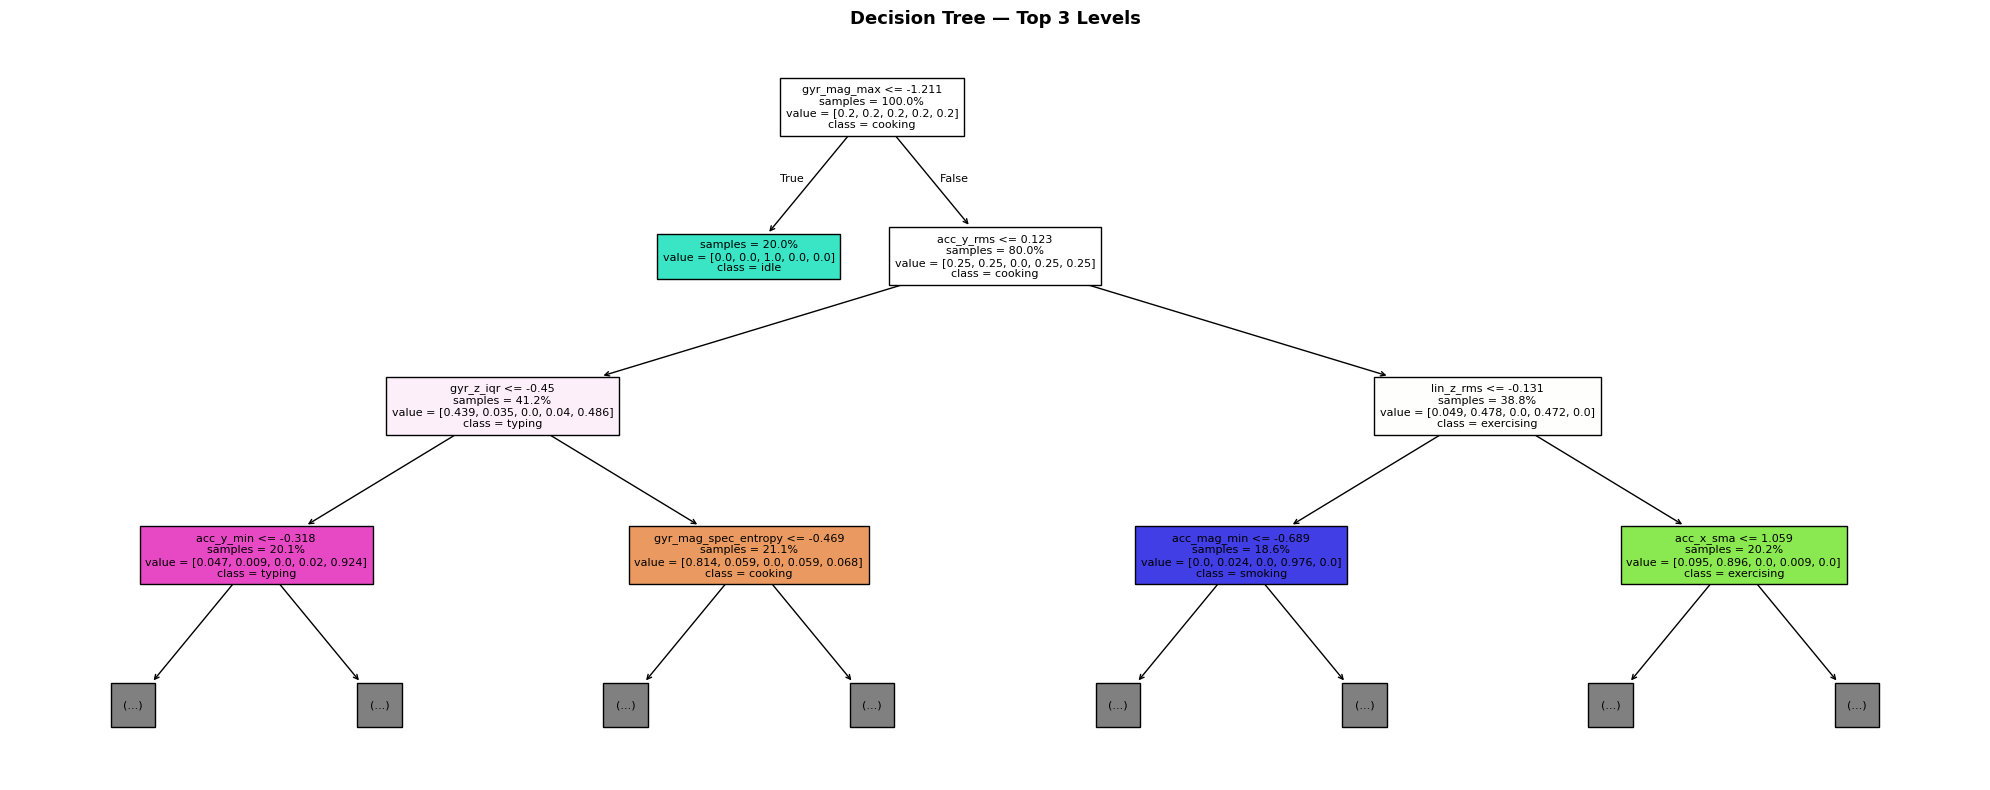

In [10]:
# ── Visualise top levels of the tree ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=feat_cols, class_names=CLASS_NAMES,
          filled=True, max_depth=3, fontsize=8,
          impurity=False, proportion=True, ax=ax)
ax.set_title("Decision Tree — Top 3 Levels", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/eda/decision_tree_viz.png", dpi=150, bbox_inches="tight")
plt.show()


## 4 · Random Forest

**Rationale:** Random Forest is an ensemble of decision trees trained on random subsets of features and samples (bagging). It corrects the high variance of a single decision tree by averaging predictions across many uncorrelated trees. It handles high-dimensional feature spaces well, is robust to irrelevant features, and provides feature importances — making it the most informative model for this task.

**Expected to be the strongest classical model** given our ~249 features and the diversity of activity motion patterns.


In [11]:
# ── Tune n_estimators by CV ───────────────────────────────────────────────────
n_trees_list = [50, 100, 200, 300]
rf_cv_scores = []

for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, max_features="sqrt",
                                random_state=42, n_jobs=-1)
    scores = cross_val_score(rf, X_train, y_train, cv=cv,
                             scoring="accuracy", n_jobs=-1)
    rf_cv_scores.append(scores.mean())
    print(f"  n_estimators={n:<4}  CV accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

best_n = n_trees_list[np.argmax(rf_cv_scores)]
print(f"\n→ Best n_estimators: {best_n} (CV accuracy: {max(rf_cv_scores):.4f})")


  n_estimators=50    CV accuracy: 0.9906 ± 0.0022
  n_estimators=100   CV accuracy: 0.9911 ± 0.0020
  n_estimators=200   CV accuracy: 0.9915 ± 0.0009
  n_estimators=300   CV accuracy: 0.9911 ± 0.0014

→ Best n_estimators: 200 (CV accuracy: 0.9915)



  Random Forest (n=200)
  Accuracy       : 0.8920
  Macro F1       : 0.8896
  Macro Precision: 0.8972
  Macro Recall   : 0.8920

Per-class report:
              precision    recall  f1-score   support

     cooking      0.918     0.696     0.792       224
  exercising      0.844     0.942     0.890       224
        idle      0.922     1.000     0.959       224
     smoking      0.822     0.929     0.872       224
      typing      0.980     0.893     0.935       224

    accuracy                          0.892      1120
   macro avg      0.897     0.892     0.890      1120
weighted avg      0.897     0.892     0.890      1120



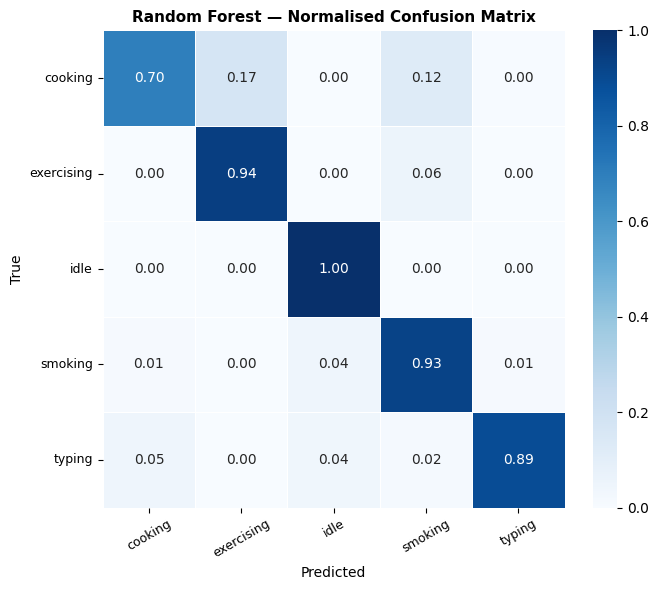

In [12]:
# ── Train & evaluate best Random Forest ───────────────────────────────────────
rf = RandomForestClassifier(n_estimators=best_n, max_features="sqrt",
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

res_rf = evaluate_model(rf, X_test, y_test, CLASS_NAMES,
                        f"Random Forest (n={best_n})")
results.append(res_rf)

plot_confusion_matrix(y_test, res_rf["y_pred"], CLASS_NAMES,
                      f"Random Forest — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/eda/cm_random_forest.png", dpi=150, bbox_inches="tight")
plt.show()


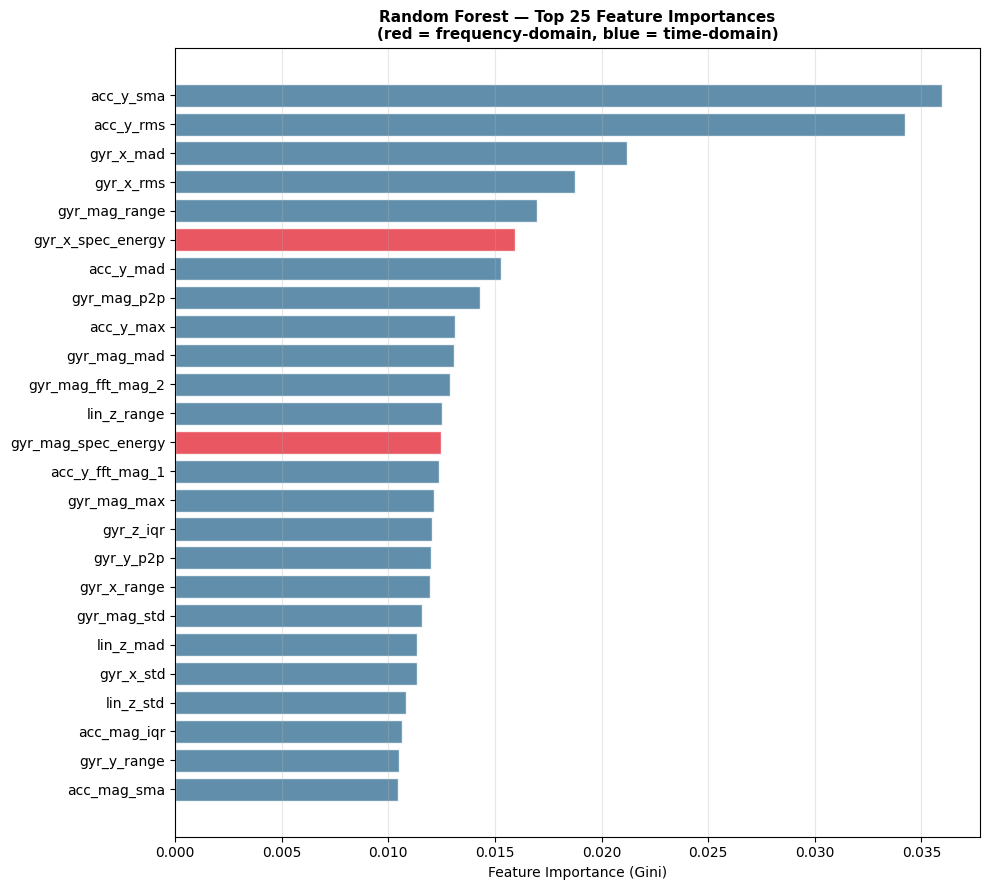

Top 10 most important features:
          feature  importance
        acc_y_sma    0.035947
        acc_y_rms    0.034230
        gyr_x_mad    0.021197
        gyr_x_rms    0.018768
    gyr_mag_range    0.016956
gyr_x_spec_energy    0.015939
        acc_y_mad    0.015262
      gyr_mag_p2p    0.014305
        acc_y_max    0.013136
      gyr_mag_mad    0.013068


In [13]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = rf.feature_importances_
imp_df = pd.DataFrame({"feature": feat_cols,
                        "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(25)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ["#e63946" if "freq" in f or "dom" in f or "spec" in f
          else "#457b9d" for f in imp_df["feature"]]
ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
        color=colors[::-1], edgecolor="white", alpha=0.85)
ax.set_xlabel("Feature Importance (Gini)", fontsize=10)
ax.set_title("Random Forest — Top 25 Feature Importances\n"
             "(red = frequency-domain, blue = time-domain)",
             fontweight="bold", fontsize=11)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/eda/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 most important features:")
print(imp_df[["feature","importance"]].head(10).to_string(index=False))


## 5 · Support Vector Machine (SVM)

**Rationale:** SVM finds the maximum-margin hyperplane separating classes in a high-dimensional feature space. With an RBF kernel it can handle non-linear boundaries — important here since activities like smoking vs idle differ subtly and may not be linearly separable. SVM performs well on normalised, high-dimensional data, which is exactly our feature matrix after StandardScaler.

**Note:** SVM is slower to train than tree-based methods on large feature matrices. We use a reduced training set via stratified sampling if needed.


Training SVM (this may take a moment)...

  SVM (RBF kernel, C=1)
  Accuracy       : 0.9134
  Macro F1       : 0.9132
  Macro Precision: 0.9174
  Macro Recall   : 0.9134

Per-class report:
              precision    recall  f1-score   support

     cooking      0.947     0.799     0.867       224
  exercising      0.921     0.933     0.927       224
        idle      0.995     0.942     0.968       224
     smoking      0.822     0.906     0.862       224
      typing      0.902     0.987     0.942       224

    accuracy                          0.913      1120
   macro avg      0.917     0.913     0.913      1120
weighted avg      0.917     0.913     0.913      1120



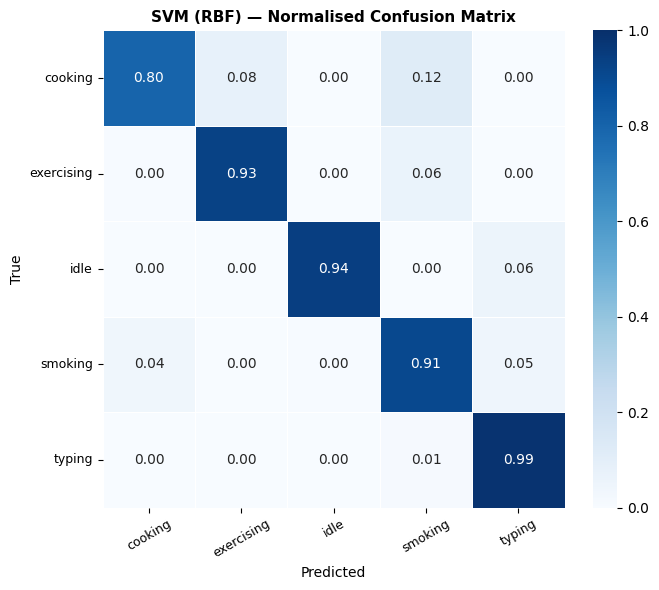

In [14]:
# ── Train SVM with RBF kernel ─────────────────────────────────────────────────
# CV for SVM is expensive — we do a single run with standard hyperparameters
# C=1 (regularisation), gamma='scale' (1 / (n_features * X.var()))
svm = SVC(kernel="rbf", C=1.0, gamma="scale",
          random_state=42, decision_function_shape="ovr")

print("Training SVM (this may take a moment)...")
svm.fit(X_train, y_train)

res_svm = evaluate_model(svm, X_test, y_test, CLASS_NAMES,
                         "SVM (RBF kernel, C=1)")
results.append(res_svm)

plot_confusion_matrix(y_test, res_svm["y_pred"], CLASS_NAMES,
                      "SVM (RBF) — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/eda/cm_svm.png", dpi=150, bbox_inches="tight")
plt.show()


## 6 · Naive Bayes

**Rationale:** Gaussian Naive Bayes is a probabilistic classifier that assumes features are conditionally independent given the class label. This assumption is clearly violated in our data (sensor axes are correlated), so NB is expected to underperform. However it serves as a useful **lower bound** — any reasonable model should beat it. It is also extremely fast to train and provides calibrated probability estimates.



  Naive Bayes
  Accuracy       : 0.8812
  Macro F1       : 0.8792
  Macro Precision: 0.8893
  Macro Recall   : 0.8812

Per-class report:
              precision    recall  f1-score   support

     cooking      1.000     0.719     0.836       224
  exercising      0.892     0.955     0.922       224
        idle      0.945     1.000     0.972       224
     smoking      0.804     0.786     0.795       224
      typing      0.806     0.946     0.871       224

    accuracy                          0.881      1120
   macro avg      0.889     0.881     0.879      1120
weighted avg      0.889     0.881     0.879      1120



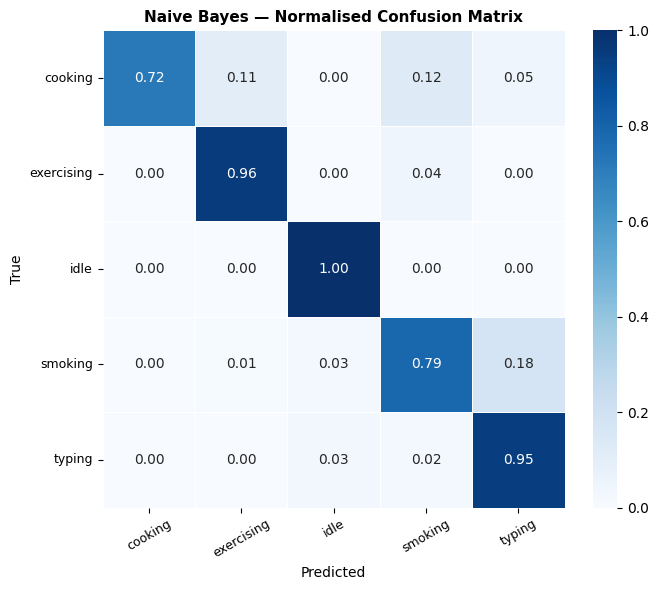

In [15]:
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

res_nb = evaluate_model(nb_model, X_test, y_test, CLASS_NAMES, "Naive Bayes")
results.append(res_nb)

plot_confusion_matrix(y_test, res_nb["y_pred"], CLASS_NAMES,
                      "Naive Bayes — Normalised Confusion Matrix")
plt.tight_layout()
plt.savefig("outputs/eda/cm_naive_bayes.png", dpi=150, bbox_inches="tight")
plt.show()


## 7 · All Confusion Matrices — Side by Side

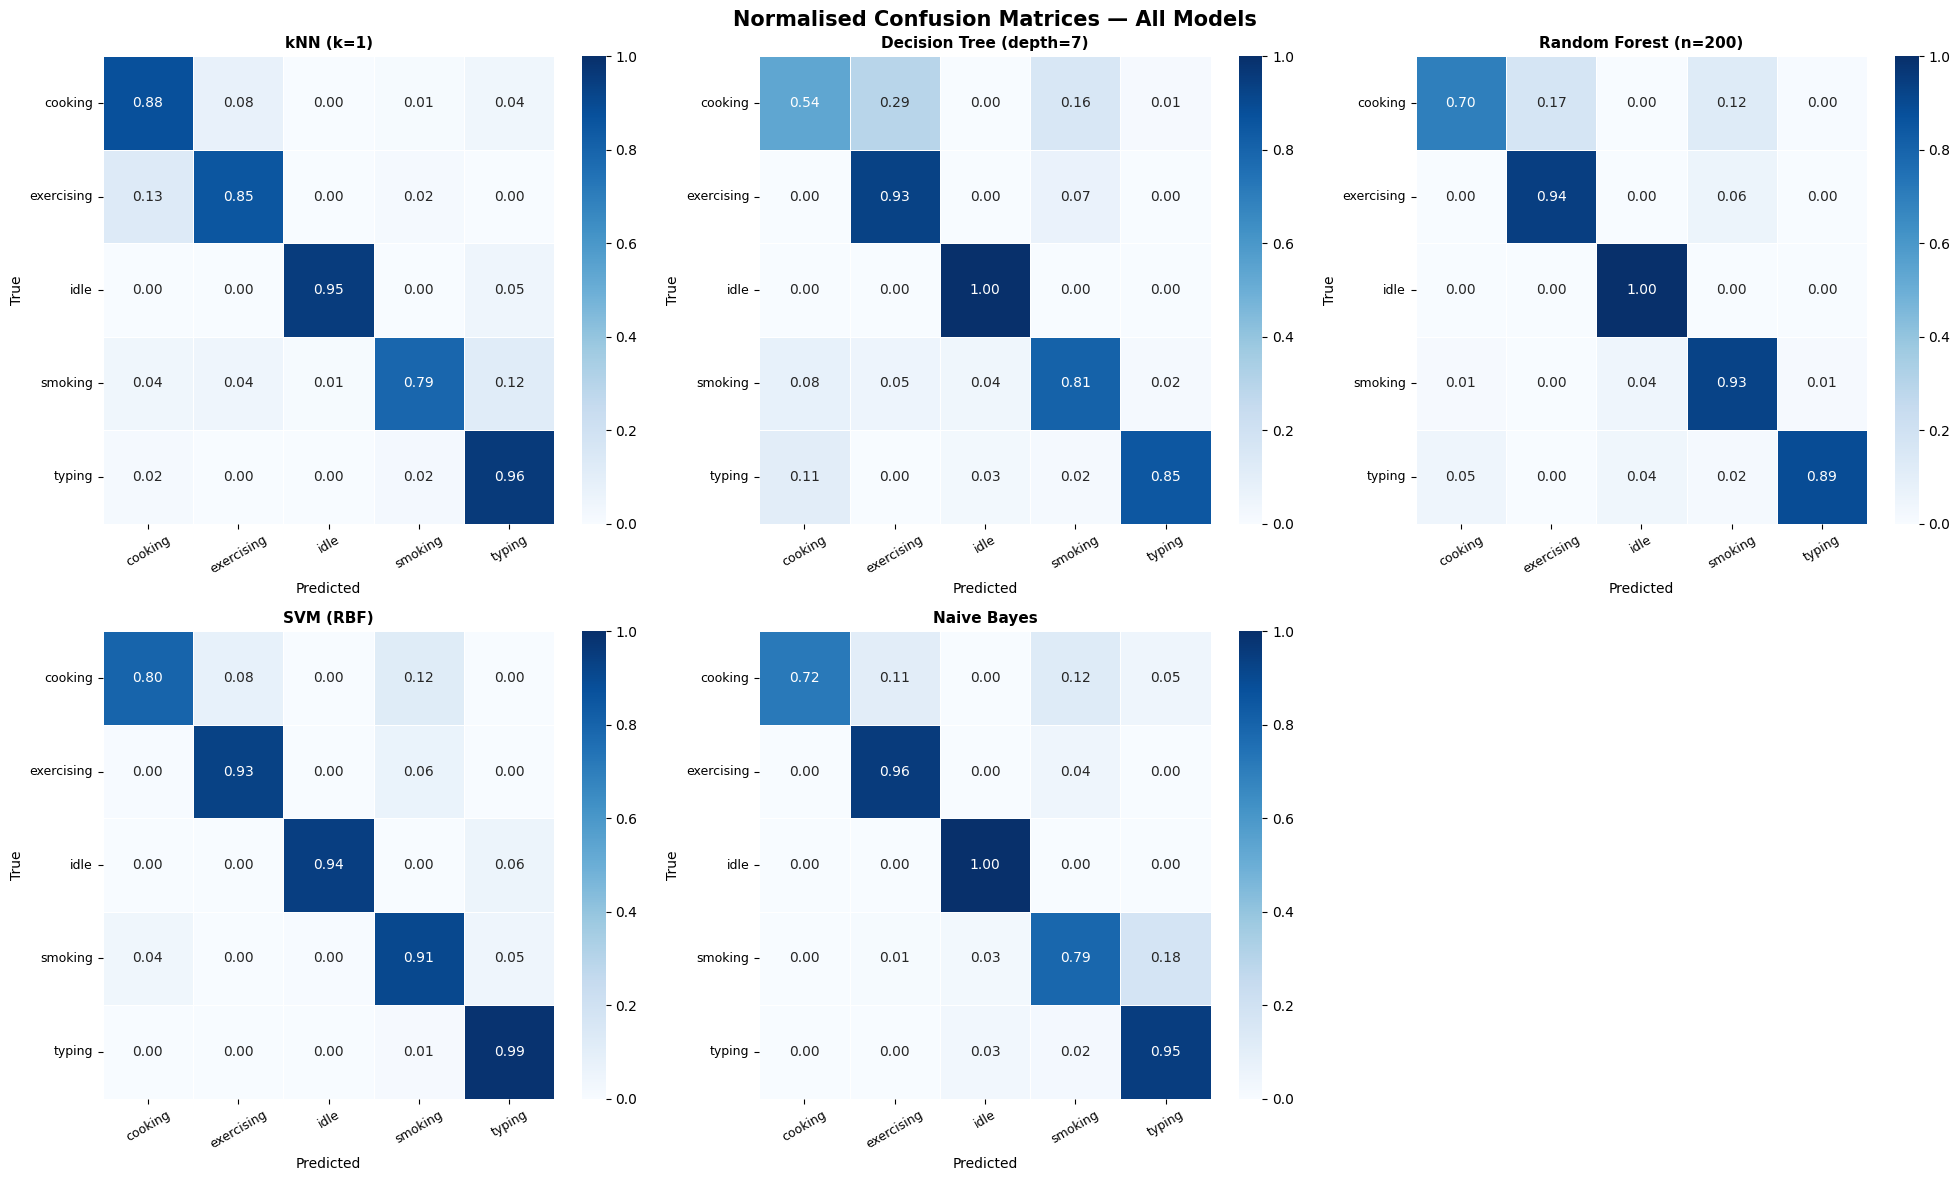

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Normalised Confusion Matrices — All Models",
             fontsize=15, fontweight="bold")

model_results = [
    (res_knn,  f"kNN (k={best_k})"),
    (res_dt,   f"Decision Tree (depth={best_depth})"),
    (res_rf,   f"Random Forest (n={best_n})"),
    (res_svm,  "SVM (RBF)"),
    (res_nb,   "Naive Bayes"),
]

for ax, (res, name) in zip(axes.flatten(), model_results):
    plot_confusion_matrix(y_test, res["y_pred"], CLASS_NAMES, name, ax=ax)

axes.flatten()[-1].set_visible(False)  # hide empty 6th cell
plt.tight_layout()
plt.savefig("outputs/eda/all_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Model Comparison

In [17]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = pd.DataFrame([{
    "Model":     r["model"],
    "Accuracy":  round(r["accuracy"],  4),
    "Macro F1":  round(r["f1_macro"],  4),
    "Precision": round(r["precision"], 4),
    "Recall":    round(r["recall"],    4),
} for r in results])

summary = summary.sort_values("Macro F1", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))


                      Model  Accuracy  Macro F1  Precision  Recall
      SVM (RBF kernel, C=1)    0.9134    0.9132     0.9174  0.9134
      Random Forest (n=200)    0.8920    0.8896     0.8972  0.8920
                  kNN (k=1)    0.8857    0.8858     0.8911  0.8857
                Naive Bayes    0.8812    0.8792     0.8893  0.8812
Decision Tree (max_depth=7)    0.8250    0.8197     0.8282  0.8250


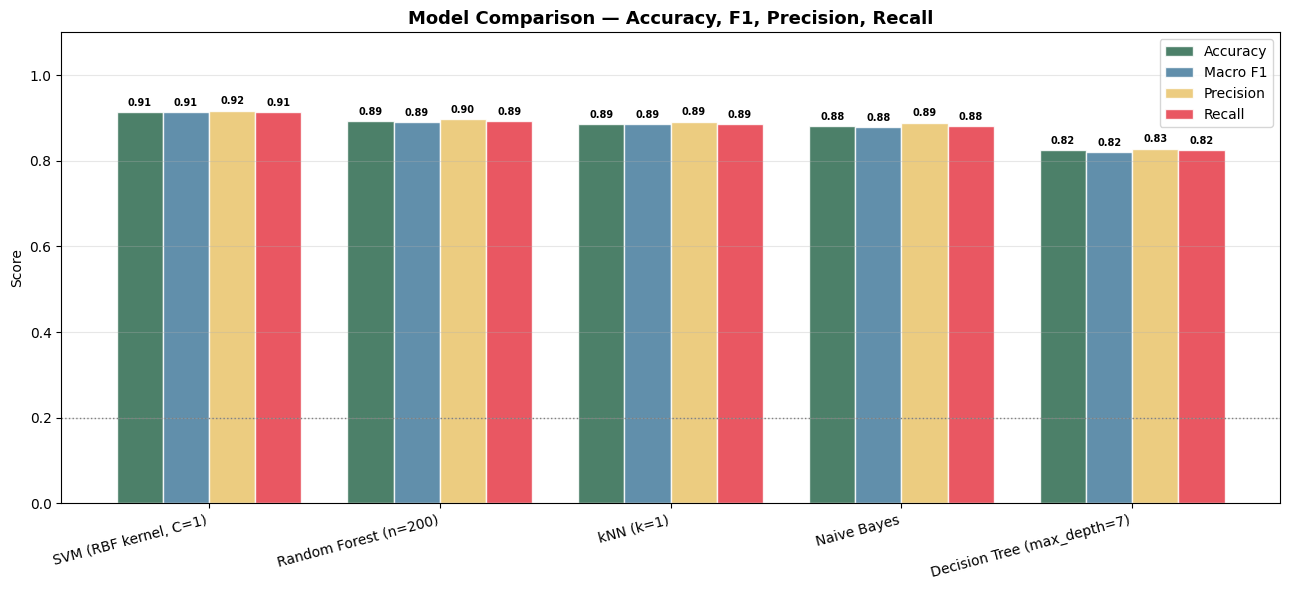

In [18]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
metrics   = ["Accuracy", "Macro F1", "Precision", "Recall"]
x         = np.arange(len(summary))
width     = 0.2
colors    = ["#2d6a4f","#457b9d","#e9c46a","#e63946"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, summary[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary["Model"], rotation=15, ha="right", fontsize=10)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Model Comparison — Accuracy, F1, Precision, Recall",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.axhline(1/len(CLASS_NAMES), color="grey", linestyle=":",
           linewidth=1, label="Random baseline")

for i, (metric, color) in enumerate(zip(metrics, colors)):
    for j, val in enumerate(summary[metric]):
        ax.text(j + i*width, val + 0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=7, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/eda/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 · Per-Class F1 Score Across Models

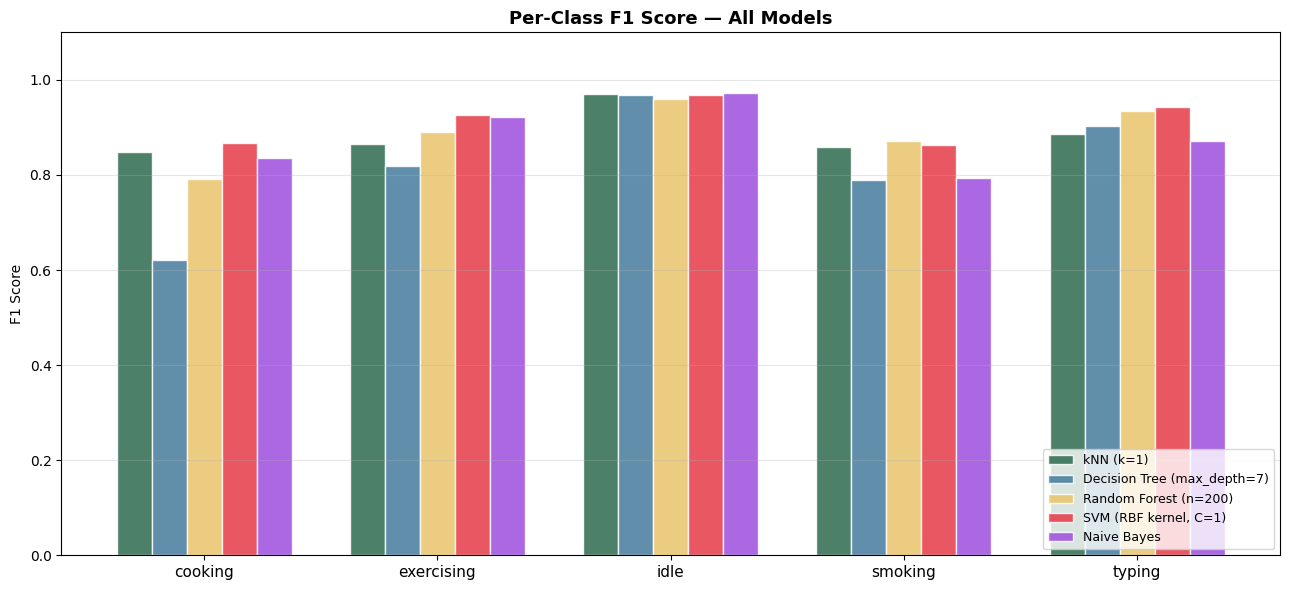


Key observations:
  → Which activity is hardest to classify? (lowest F1 across models)
  → Are smoking and idle being confused with each other?
  → Does exercising have near-perfect F1? (expected — strongest signal)


In [19]:
from sklearn.metrics import f1_score

fig, ax = plt.subplots(figsize=(13, 6))
x     = np.arange(len(CLASS_NAMES))
width = 0.15
model_colors = ["#2d6a4f","#457b9d","#e9c46a","#e63946","#9d4edd"]

for i, (res, color) in enumerate(zip(results, model_colors)):
    per_class_f1 = f1_score(y_test, res["y_pred"],
                             average=None, labels=range(len(CLASS_NAMES)))
    ax.bar(x + i*width, per_class_f1, width,
           label=res["model"], color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width * 2)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.1)
ax.set_title("Per-Class F1 Score — All Models", fontweight="bold", fontsize=13)
ax.legend(fontsize=9, loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/eda/per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey observations:")
print("  → Which activity is hardest to classify? (lowest F1 across models)")
print("  → Are smoking and idle being confused with each other?")
print("  → Does exercising have near-perfect F1? (expected — strongest signal)")


## 10 · Cross-Validation on Training Set

5-fold stratified cross-validation on the training set gives a more reliable estimate of generalisation performance than a single train/test split. The test set (subject_2) remains held out.


In [20]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    f"kNN (k={best_k})":              KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1),
    f"Decision Tree (d={best_depth})": DecisionTreeClassifier(max_depth=best_depth, random_state=42),
    f"Random Forest (n={best_n})":     RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1),
    "SVM (RBF)":                       SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42),
    "Naive Bayes":                     GaussianNB(),
}

cv_results = {}
print("5-Fold Stratified Cross-Validation (train set only):")
print(f"{'Model':<35} {'Mean Acc':>10} {'Std':>8}")
print("-" * 55)

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train, y_train,
                             cv=cv5, scoring="accuracy", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<35} {scores.mean():>10.4f} {scores.std():>8.4f}")


5-Fold Stratified Cross-Validation (train set only):
Model                                 Mean Acc      Std
-------------------------------------------------------
kNN (k=1)                               0.9955   0.0042
Decision Tree (d=7)                     0.9728   0.0133
Random Forest (n=200)                   0.9915   0.0009
SVM (RBF)                               0.9951   0.0030
Naive Bayes                             0.9406   0.0077


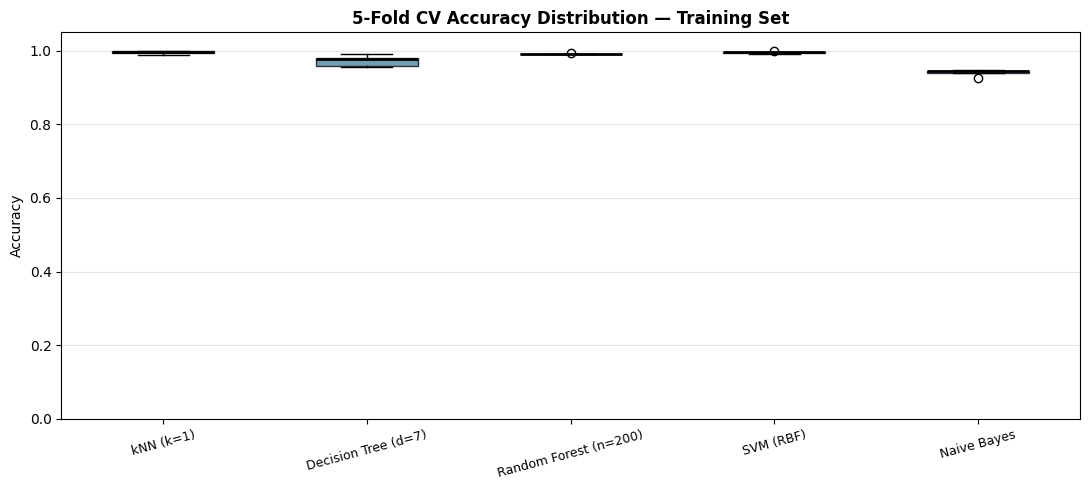

In [21]:
# ── CV boxplot ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
data_to_plot = [cv_results[m] for m in cv_models]
labels       = list(cv_models.keys())
bp = ax.boxplot(data_to_plot, patch_artist=True, labels=labels,
                medianprops=dict(color="black", linewidth=2))

box_colors = ["#2d6a4f","#457b9d","#e9c46a","#e63946","#9d4edd"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_ylabel("Accuracy")
ax.set_title("5-Fold CV Accuracy Distribution — Training Set",
             fontweight="bold", fontsize=12)
ax.tick_params(axis="x", rotation=15, labelsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig("outputs/eda/cv_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()


## 11 · Error Analysis — What Is the Best Model Getting Wrong?

Focus on the best model (expected: Random Forest) and analyse misclassifications in detail.


In [22]:
# Use best model by macro F1
best_result = max(results, key=lambda r: r["f1_macro"])
best_name   = best_result["model"]
y_pred_best = best_result["y_pred"]

print(f"Best model: {best_name}  (macro F1 = {best_result['f1_macro']:.4f})")

# ── Misclassification breakdown ───────────────────────────────────────────────
errors = pd.DataFrame({
    "true":      [CLASS_NAMES[i] for i in y_test],
    "predicted": [CLASS_NAMES[i] for i in y_pred_best]
})
errors = errors[errors["true"] != errors["predicted"]]
print(f"\nTotal misclassifications: {len(errors)} / {len(y_test)} "
      f"({100*len(errors)/len(y_test):.1f}%)")

print("\nMost common confusion pairs:")
pair_counts = (errors.groupby(["true","predicted"])
                     .size()
                     .reset_index(name="count")
                     .sort_values("count", ascending=False))
print(pair_counts.head(10).to_string(index=False))


Best model: SVM (RBF kernel, C=1)  (macro F1 = 0.9132)

Total misclassifications: 97 / 1120 (8.7%)

Most common confusion pairs:
      true  predicted  count
   cooking    smoking     27
   cooking exercising     18
exercising    smoking     14
      idle     typing     13
   smoking     typing     11
   smoking    cooking      9
    typing    smoking      3
exercising    cooking      1
   smoking       idle      1


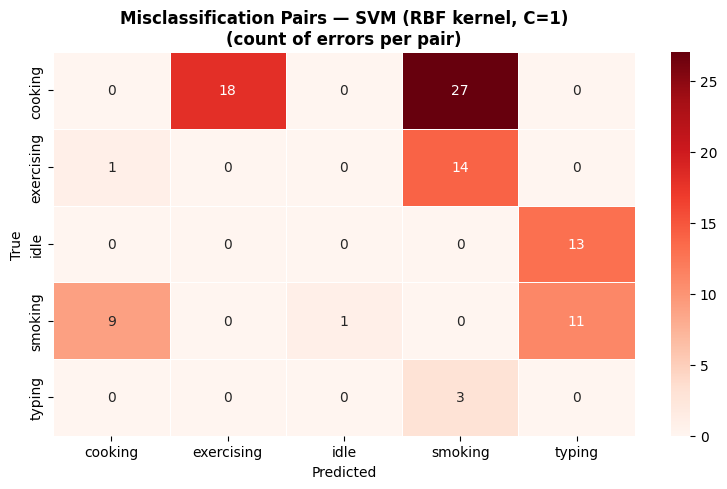

In [23]:
# ── Heatmap of confusion pairs ────────────────────────────────────────────────
pivot = pair_counts.pivot(index="true", columns="predicted", values="count").fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="Reds",
            linewidths=0.5, ax=ax)
ax.set_title(f"Misclassification Pairs — {best_name}\n(count of errors per pair)",
             fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.savefig("outputs/eda/error_analysis_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 12 · Save Models & Results

In [24]:
# Save all trained models
model_objects = {
    "knn": knn,
    "decision_tree": dt,
    "random_forest": rf,
    "svm": svm,
    "naive_bayes": nb_model
}

for name, model in model_objects.items():
    with open(f"outputs/models/{name}.pkl", "wb") as f:
        pickle.dump(model, f)

# Save summary table
summary.to_csv("outputs/models/model_comparison.csv", index=False)

print("✅ Saved models to outputs/models/")
print("✅ Saved model_comparison.csv")
print(f"\n{'='*55}")
print("  FINAL RESULTS SUMMARY")
print(f"{'='*55}")
print(summary.to_string(index=False))
print(f"\nBest model : {best_name}")
print(f"Best Macro F1 : {best_result['f1_macro']:.4f}")
print(f"Best Accuracy : {best_result['accuracy']:.4f}")


✅ Saved models to outputs/models/
✅ Saved model_comparison.csv

  FINAL RESULTS SUMMARY
                      Model  Accuracy  Macro F1  Precision  Recall
      SVM (RBF kernel, C=1)    0.9134    0.9132     0.9174  0.9134
      Random Forest (n=200)    0.8920    0.8896     0.8972  0.8920
                  kNN (k=1)    0.8857    0.8858     0.8911  0.8857
                Naive Bayes    0.8812    0.8792     0.8893  0.8812
Decision Tree (max_depth=7)    0.8250    0.8197     0.8282  0.8250

Best model : SVM (RBF kernel, C=1)
Best Macro F1 : 0.9132
Best Accuracy : 0.9134


Training Voting Hard...

  Voting Classifier (Hard)
  Accuracy       : 0.9330
  Macro F1       : 0.9325
  Macro Precision: 0.9335
  Macro Recall   : 0.9330

Per-class report:
              precision    recall  f1-score   support

     cooking      0.925     0.826     0.873       224
  exercising      0.926     0.946     0.936       224
        idle      0.995     0.978     0.986       224
     smoking      0.881     0.924     0.902       224
      typing      0.941     0.991     0.965       224

    accuracy                          0.933      1120
   macro avg      0.934     0.933     0.932      1120
weighted avg      0.934     0.933     0.932      1120


Training Voting Soft...

  Voting Classifier (Soft)
  Accuracy       : 0.9268
  Macro F1       : 0.9266
  Macro Precision: 0.9283
  Macro Recall   : 0.9268

Per-class report:
              precision    recall  f1-score   support

     cooking      0.907     0.875     0.891       224
  exercising      0.909     0.938     0.923       2

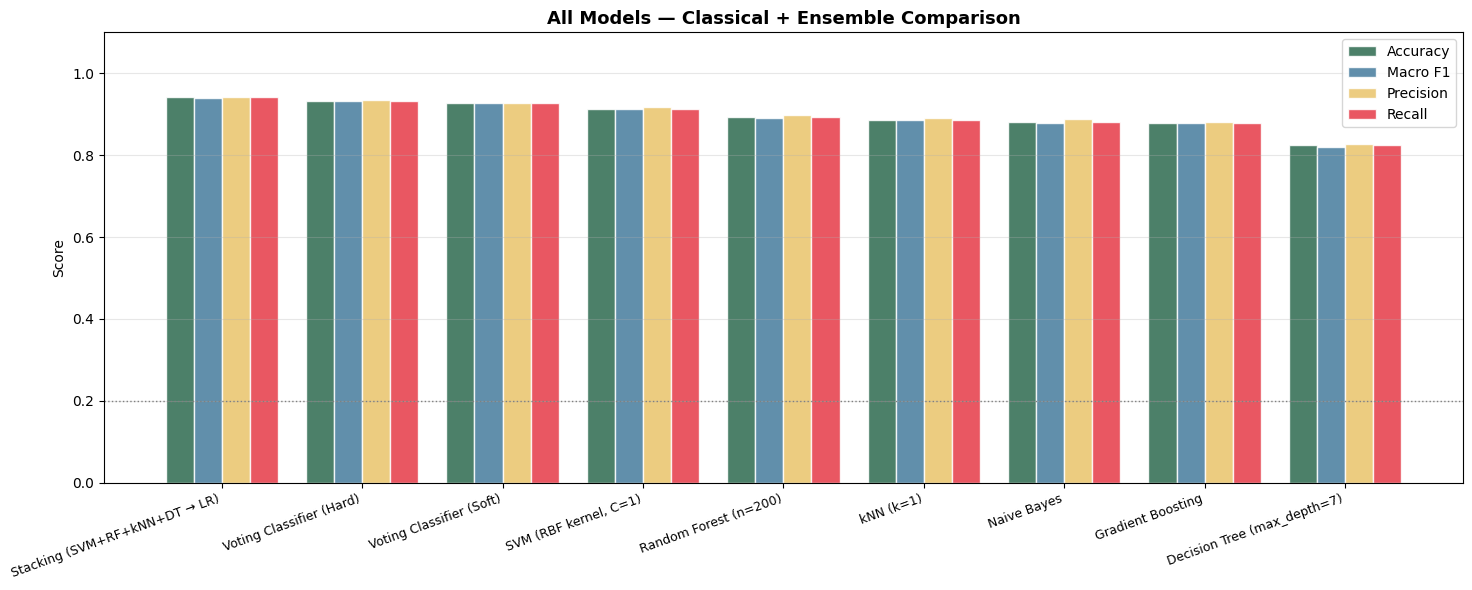


Best ensemble: Stacking (SVM+RF+kNN+DT → LR)  (F1=0.9407)


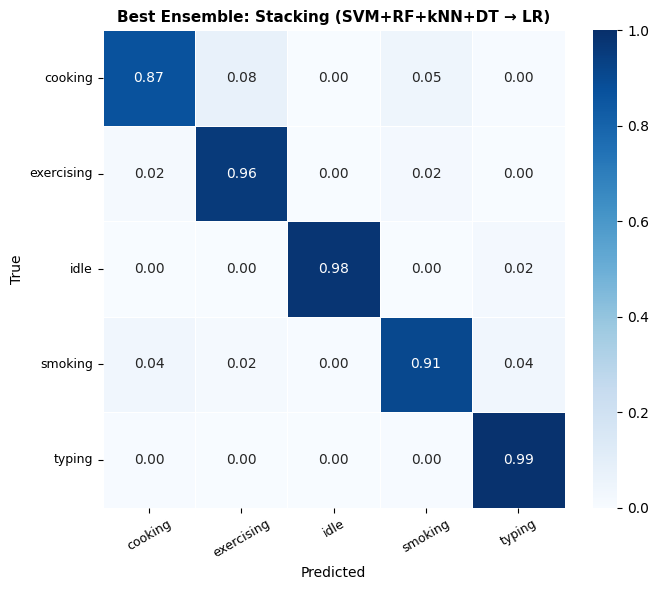


✅ Ensemble models saved


In [25]:
from sklearn.ensemble import (VotingClassifier, BaggingClassifier,
                               GradientBoostingClassifier, StackingClassifier)
from sklearn.linear_model import LogisticRegression
import pickle

# ── Load best hyperparams from earlier ────────────────────────────────────────
# (run this in the same notebook session so best_k, best_n, best_depth exist)

# ═══════════════════════════════════════════════════════
# ENSEMBLE 1 — Voting Classifier (Hard & Soft)
# ═══════════════════════════════════════════════════════
# Combines predictions from SVM + RF + kNN by majority vote
# Hard voting: majority class label wins
# Soft voting: averages predicted probabilities — generally better
# SVM needs probability=True for soft voting (slightly slower to train)

svm_prob = SVC(kernel="rbf", C=1.0, gamma="scale",
               probability=True, random_state=42)

voting_hard = VotingClassifier(
    estimators=[
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
        ("rf",  RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)),
        ("knn", KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
    ],
    voting="hard"
)

voting_soft = VotingClassifier(
    estimators=[
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale",
                    probability=True, random_state=42)),
        ("rf",  RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)),
        ("knn", KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
    ],
    voting="soft"
)

print("Training Voting Hard...")
voting_hard.fit(X_train, y_train)
res_vh = evaluate_model(voting_hard, X_test, y_test, CLASS_NAMES,
                        "Voting Classifier (Hard)")
results.append(res_vh)

print("\nTraining Voting Soft...")
voting_soft.fit(X_train, y_train)
res_vs = evaluate_model(voting_soft, X_test, y_test, CLASS_NAMES,
                        "Voting Classifier (Soft)")
results.append(res_vs)

# ═══════════════════════════════════════════════════════
# ENSEMBLE 2 — Gradient Boosting
# ═══════════════════════════════════════════════════════
# Builds trees sequentially — each tree corrects the errors of the previous
# Often outperforms Random Forest when tuned but slower to train
# n_estimators=100, learning_rate=0.1 is a solid starting point

gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                 max_depth=5, random_state=42)
print("\nTraining Gradient Boosting (this takes a minute)...")
gb.fit(X_train, y_train)
res_gb = evaluate_model(gb, X_test, y_test, CLASS_NAMES,
                        "Gradient Boosting")
results.append(res_gb)

# ═══════════════════════════════════════════════════════
# ENSEMBLE 3 — Stacking
# ═══════════════════════════════════════════════════════
# Base models make predictions → meta-model (Logistic Regression)
# learns how to best combine those predictions
# More sophisticated than voting — learns which base model to trust per class

stacking = StackingClassifier(
    estimators=[
        ("svm", SVC(kernel="rbf", C=1.0, gamma="scale",
                    probability=True, random_state=42)),
        ("rf",  RandomForestClassifier(n_estimators=best_n, random_state=42, n_jobs=-1)),
        ("knn", KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)),
        ("dt",  DecisionTreeClassifier(max_depth=best_depth, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,          # uses 5-fold CV to generate meta-features (avoids leakage)
    n_jobs=-1
)

print("\nTraining Stacking Classifier (slowest — be patient)...")
stacking.fit(X_train, y_train)
res_stack = evaluate_model(stacking, X_test, y_test, CLASS_NAMES,
                           "Stacking (SVM+RF+kNN+DT → LR)")
results.append(res_stack)

# ═══════════════════════════════════════════════════════
# FULL COMPARISON TABLE
# ═══════════════════════════════════════════════════════
summary_all = pd.DataFrame([{
    "Model":     r["model"],
    "Accuracy":  round(r["accuracy"],  4),
    "Macro F1":  round(r["f1_macro"],  4),
    "Precision": round(r["precision"], 4),
    "Recall":    round(r["recall"],    4),
} for r in results]).sort_values("Macro F1", ascending=False).reset_index(drop=True)

print("\n" + "="*65)
print("  FULL MODEL COMPARISON (including ensembles)")
print("="*65)
print(summary_all.to_string(index=False))

# ═══════════════════════════════════════════════════════
# PLOT — All models including ensembles
# ═══════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(15, 6))
x      = np.arange(len(summary_all))
width  = 0.2
colors = ["#2d6a4f","#457b9d","#e9c46a","#e63946"]

for i, (metric, color) in enumerate(zip(["Accuracy","Macro F1","Precision","Recall"], colors)):
    ax.bar(x + i*width, summary_all[metric], width,
           label=metric, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(summary_all["Model"], rotation=20, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("All Models — Classical + Ensemble Comparison",
             fontweight="bold", fontsize=13)
ax.legend(fontsize=10)
ax.axhline(1/len(CLASS_NAMES), color="grey", linestyle=":",
           linewidth=1, label="Random baseline")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/eda/model_comparison_full.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Confusion matrix for best ensemble ────────────────────────────────────────
best_ensemble = max([res_vh, res_vs, res_gb, res_stack],
                     key=lambda r: r["f1_macro"])
print(f"\nBest ensemble: {best_ensemble['model']}  "
      f"(F1={best_ensemble['f1_macro']:.4f})")

plot_confusion_matrix(y_test, best_ensemble["y_pred"], CLASS_NAMES,
                      f"Best Ensemble: {best_ensemble['model']}")
plt.tight_layout()
plt.savefig("outputs/eda/cm_best_ensemble.png", dpi=150, bbox_inches="tight")
plt.show()

# Save ensembles
for name, model in [("voting_hard", voting_hard), ("voting_soft", voting_soft),
                     ("gradient_boosting", gb), ("stacking", stacking)]:
    with open(f"outputs/models/{name}.pkl", "wb") as f:
        pickle.dump(model, f)
print("\n✅ Ensemble models saved")